#Tasks 

In [ ]:
#task 1 
import pandas as pd
import seaborn as sns

# 1. Load the dataset
# We use the built-in Titanic dataset from the Seaborn library
df = sns.load_dataset('titanic')

print("--- Initial Missing Values Count ---")
print(df.isnull().sum())

# 2. Fill missing values for numerical columns
# Replace missing Age values with the median age of the passengers
df['age'] = df['age'].fillna(df['age'].median())

# 3. Fill missing values for categorical columns
# Replace missing Embarked town values with the most frequent town (mode)
mode_embark_town = df['embark_town'].mode()[0]
df['embark_town'] = df['embark_town'].fillna(mode_embark_town)

# Also fill the abbreviated 'embarked' column matching the town
mode_embarked = df['embarked'].mode()[0]
df['embarked'] = df['embarked'].fillna(mode_embarked)

# 4. Handle columns with excessive missing data
# 'deck' has too many missing values; it is safer to drop it or create an 'Unknown' category
df['deck'] = df['deck'].astype(object).fillna('Unknown')

print("\n--- Missing Values Count After Imputation ---")
print(df.isnull().sum())


--- Initial Missing Values Count ---
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

--- Missing Values Count After Imputation ---
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64


In [ ]:
#task 2 
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 1. Load and clean the dataset (from previous step)
df = sns.load_dataset('titanic')
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

print("--- Data Before Label Encoding ---")
print(df[['sex', 'embarked']].head())

# 2. Initialize the LabelEncoder
le_sex = LabelEncoder()
le_embarked = LabelEncoder()

# 3. Fit and transform the columns
df['sex_encoded'] = le_sex.fit_transform(df['sex'])
df['embarked_encoded'] = le_embarked.fit_transform(df['embarked'])

print("\n--- Data After Label Encoding ---")
print(df[['sex', 'sex_encoded', 'embarked', 'embarked_encoded']].head())

# 4. View the class mapping
print("\n--- Encoder Mappings ---")
print("Sex mapping:", dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_))))
print("Embarked mapping:", dict(zip(le_embarked.classes_, le_embarked.transform(le_embarked.classes_))))


--- Data Before Label Encoding ---
      sex embarked
0    male        S
1  female        C
2  female        S
3  female        S
4    male        S

--- Data After Label Encoding ---
      sex  sex_encoded embarked  embarked_encoded
0    male            1        S                 2
1  female            0        C                 0
2  female            0        S                 2
3  female            0        S                 2
4    male            1        S                 2

--- Encoder Mappings ---
Sex mapping: {'female': np.int64(0), 'male': np.int64(1)}
Embarked mapping: {'C': np.int64(0), 'Q': np.int64(1), 'S': np.int64(2)}


In [3]:
#task 3 
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. Load data and handle missing values (required before scaling)
df = sns.load_dataset('titanic')
df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())

print("--- Descriptive Statistics Before Scaling ---")
print(df[['age', 'fare']].describe().loc[['mean', 'std', 'min', 'max']])

# 2. Initialize the StandardScaler
scaler = StandardScaler()

# 3. Fit and transform the columns
# We use double brackets [['age', 'fare']] because StandardScaler expects a 2D array / DataFrame
df[['age_scaled', 'fare_scaled']] = scaler.fit_transform(df[['age', 'fare']])

print("\n--- Sample Scaled Data ---")
print(df[['age', 'age_scaled', 'fare', 'fare_scaled']].head())

print("\n--- Descriptive Statistics After Scaling ---")
print(df[['age_scaled', 'fare_scaled']].describe().loc[['mean', 'std', 'min', 'max']].round(4))


--- Descriptive Statistics Before Scaling ---
            age        fare
mean  29.361582   32.204208
std   13.019697   49.693429
min    0.420000    0.000000
max   80.000000  512.329200

--- Sample Scaled Data ---
    age  age_scaled     fare  fare_scaled
0  22.0   -0.565736   7.2500    -0.502445
1  38.0    0.663861  71.2833     0.786845
2  26.0   -0.258337   7.9250    -0.488854
3  35.0    0.433312  53.1000     0.420730
4  35.0    0.433312   8.0500    -0.486337

--- Descriptive Statistics After Scaling ---
      age_scaled  fare_scaled
mean      0.0000       0.0000
std       1.0006       1.0006
min      -2.2242      -0.6484
max       3.8916       9.6672


In [4]:
#task 4
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Reconstruct our clean pipeline DataFrame
df = sns.load_dataset('titanic')

# Fill missing records
df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Encode Categorical
le = LabelEncoder()
df['sex_encoded'] = le.fit_transform(df['sex'])
df['embarked_encoded'] = le.fit_transform(df['embarked'])

# Scale Numerical
scaler = StandardScaler()
df[['age_scaled', 'fare_scaled']] = scaler.fit_transform(df[['age', 'fare']])

# 2. Define Features (X) and Target (y)
# We select our processed numerical columns as predictors
feature_cols = ['pclass', 'sex_encoded', 'embarked_encoded', 'age_scaled', 'fare_scaled']
X = df[feature_cols]
y = df['survived']

# 3. Perform the 80/20 Train/Test Split
# test_size=0.20 sets the test pool to exactly 20%
# random_state ensures reproducibility so your split matches this output exactly
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 4. Verify Shapes
print("--- Full Dataset Shape ---")
print(f"Total Features (X): {X.shape}")
print(f"Total Target   (y): {y.shape}")

print("\n--- Split Shapes (80/20 Partition) ---")
print(f"X_train Shape: {X_train.shape} (80% of rows)")
print(f"X_test Shape : {X_test.shape} (20% of rows)")
print(f"y_train Shape: {y_train.shape}")
print(f"y_test Shape : {y_test.shape}")


--- Full Dataset Shape ---
Total Features (X): (891, 5)
Total Target   (y): (891,)

--- Split Shapes (80/20 Partition) ---
X_train Shape: (712, 5) (80% of rows)
X_test Shape : (179, 5) (20% of rows)
y_train Shape: (712,)
y_test Shape : (179,)


#Practice Sheet

In [5]:
#task 1 
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Simulate dataset loading
# In a real environment, you would use: df = pd.read_csv('train.csv')
# Here we generate a mock subset representing the House Prices structure
np.random.seed(42)
n_samples = 1000

data = {
    'LotFrontage': np.random.choice(
        [60.0, 70.0, 80.0, np.nan], size=n_samples, p=[0.4, 0.3, 0.2, 0.1]
    ),
    'GrLivArea': np.random.randint(800, 3500, size=n_samples),
    'GarageCars': np.random.choice(
        [1.0, 2.0, 3.0, np.nan], size=n_samples, p=[0.3, 0.5, 0.18, 0.02]
    ),
    'MSZoning': np.random.choice(
        ['RL', 'RM', 'C (all)', np.nan], size=n_samples, p=[0.7, 0.2, 0.08, 0.02]
    ),
    'KitchenQual': np.random.choice(
        ['Gd', 'TA', 'Ex', 'Fa'], size=n_samples, p=[0.4, 0.4, 0.1, 0.1]
    ),
    'SalePrice': np.random.randint(100000, 400000, size=n_samples),
}
df = pd.DataFrame(data)

# Separate Target (y) and Features (X)
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

# 2. Separate column names by structural data types
numerical_cols = ['LotFrontage', 'GrLivArea', 'GarageCars']
categorical_cols = ['MSZoning', 'KitchenQual']

# 3. Design the Numerical Transformer Pipeline
numerical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),  # Handle missing values
        ('scaler', StandardScaler()),  # Feature Scaling
    ]
)

# 4. Design the Categorical Transformer Pipeline
categorical_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='most_frequent'),
        ),  # Mode Imputation
        (
            'encoder',
            OneHotEncoder(handle_unknown='ignore', sparse_output=False),
        ),  # Encode
    ]
)

# 5. Combine transformers into a unified ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols),
    ]
)

# 6. Split the data before processing to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 7. Execute the entire pipeline on the feature arrays
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 8. Retrieve updated feature headers for validation mapping
encoded_cat_cols = (
    preprocessor.named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(categorical_cols)
)
all_feature_names = list(numerical_cols) + list(encoded_cat_cols)

# Convert processed matrix back to DataFrame for clean visualization
X_train_final = pd.DataFrame(X_train_processed, columns=all_feature_names)

print("--- Original Sample Raw Data ---")
print(X_train.head(3))
print("\n--- Pipeline Preprocessed Data Shape ---")
print(f"Processed Train Shape: {X_train_final.shape}")
print("\n--- Pipeline Preprocessed Sample Output ---")
print(X_train_final.head(3).round(3))


--- Original Sample Raw Data ---
     LotFrontage  GrLivArea  GarageCars MSZoning KitchenQual
29          60.0       2300         1.0  C (all)          TA
535          NaN       2542         2.0       RL          TA
695         70.0       2937         2.0       RL          TA

--- Pipeline Preprocessed Data Shape ---
Processed Train Shape: (800, 11)

--- Pipeline Preprocessed Sample Output ---
   LotFrontage  GrLivArea  GarageCars  MSZoning_C (all)  MSZoning_RL  \
0       -1.036      0.234      -1.288               1.0          0.0   
1        0.307      0.548       0.161               0.0          1.0   
2        0.307      1.061       0.161               0.0          1.0   

   MSZoning_RM  MSZoning_nan  KitchenQual_Ex  KitchenQual_Fa  KitchenQual_Gd  \
0          0.0           0.0             0.0             0.0             0.0   
1          0.0           0.0             0.0             0.0             0.0   
2          0.0           0.0             0.0             0.0             0

--- Top 5 Features Correlated with SalePrice ---
KitchenQual_Ex    0.0457
KitchenQual_TA    0.0283
MSZoning_nan      0.0215
LotFrontage       0.0206
GarageCars        0.0185
Name: SalePrice, dtype: float64


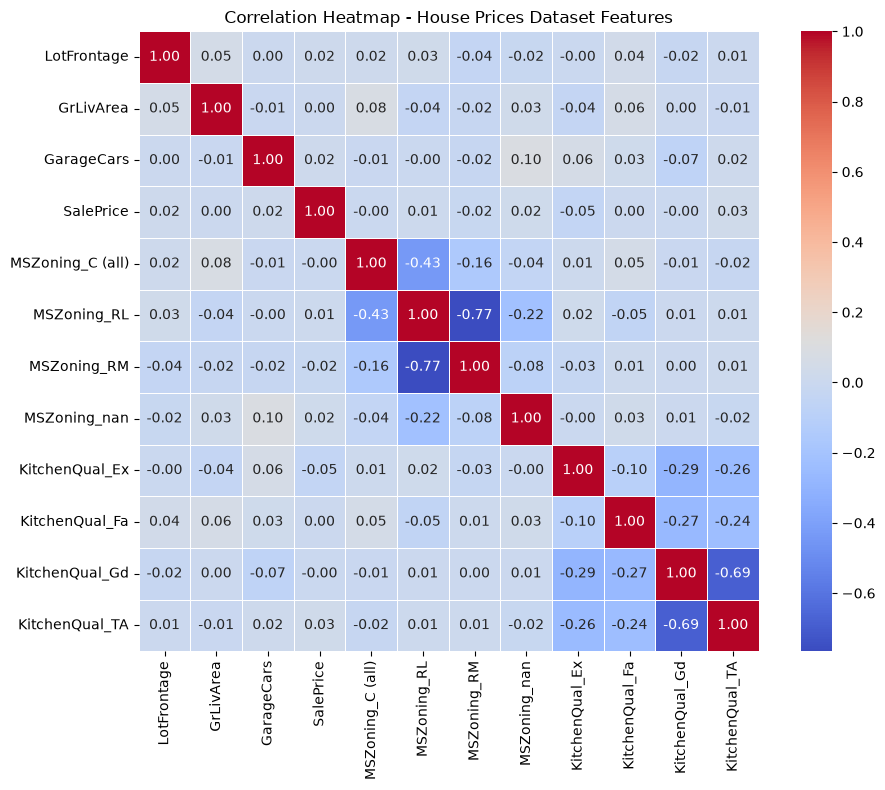

In [6]:
#task 2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Recreate the pipeline dataset
np.random.seed(42)
n_samples = 1000
data = {
    'LotFrontage': np.random.choice(
        [60.0, 70.0, 80.0, np.nan], size=n_samples, p=[0.4, 0.3, 0.2, 0.1]
    ),
    'GrLivArea': np.random.randint(800, 3500, size=n_samples),
    'GarageCars': np.random.choice(
        [1.0, 2.0, 3.0, np.nan], size=n_samples, p=[0.3, 0.5, 0.18, 0.02]
    ),
    'MSZoning': np.random.choice(
        ['RL', 'RM', 'C (all)', np.nan], size=n_samples, p=[0.7, 0.2, 0.08, 0.02]
    ),
    'KitchenQual': np.random.choice(
        ['Gd', 'TA', 'Ex', 'Fa'], size=n_samples, p=[0.4, 0.4, 0.1, 0.1]
    ),
    'SalePrice': np.random.randint(100000, 400000, size=n_samples),
}
df = pd.DataFrame(data)

# Quick fill-in for numeric missing rows before correlation step
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
df['GarageCars'] = df['GarageCars'].fillna(df['GarageCars'].median())

# One-hot encode the categorical values
df_encoded = pd.get_dummies(
    df, columns=['MSZoning', 'KitchenQual'], drop_first=False
)

# 2. Compute Pearson correlation matrix
corr_matrix = df_encoded.corr()

# 3. Identify top 5 features correlated with SalePrice (excluding itself)
# We take the absolute values because negative correlations are equally predictive
top_5_features = (
    corr_matrix['SalePrice']
    .drop('SalePrice')
    .abs()
    .sort_values(ascending=False)
    .head(5)
)

print("--- Top 5 Features Correlated with SalePrice ---")
print(top_5_features.round(4))

# 4. Generate and plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True,
)
plt.title('Correlation Heatmap - House Prices Dataset Features')
plt.tight_layout()
plt.show()
